In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split



In [3]:
df  = pd.read_csv("/content/fashion-mnist_test.csv")

In [4]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [8]:
X = df.drop("label", axis=1)
Y = df["label"]

In [9]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [24]:
X_train = X_train.to_numpy()
X_test  = X_test.to_numpy()

In [25]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

In [26]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

In [27]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [28]:
model = Sequential()
model.add(Conv2D(64,kernel_size=(3,3),activation="relu",input_shape=(28, 28, 1)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,kernel_size=(3,3),activation="relu"))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [30]:
model.fit(X_train,Y_train,epochs=10,validation_data=(X_test,Y_test))

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6227 - loss: 1.0329 - val_accuracy: 0.7860 - val_loss: 0.5890
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.7653 - loss: 0.6360 - val_accuracy: 0.8225 - val_loss: 0.5140
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7918 - loss: 0.5570 - val_accuracy: 0.8305 - val_loss: 0.4661
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8101 - loss: 0.5155 - val_accuracy: 0.8260 - val_loss: 0.4592
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.8192 - loss: 0.4819 - val_accuracy: 0.8435 - val_loss: 0.4307
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8319 - loss: 0.4488 - val_accuracy: 0.8480 - val_loss: 0.4231
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8480 - loss: 0.4131 - val_accuracy: 0.8500 - val_loss: 0.4175
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8519 - loss: 0.3993 - va

In [31]:
predictions = model.predict(X_test)



63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [32]:
import matplotlib.pyplot as plt


In [34]:
import numpy as np

y_pred = np.argmax(predictions, axis=1)

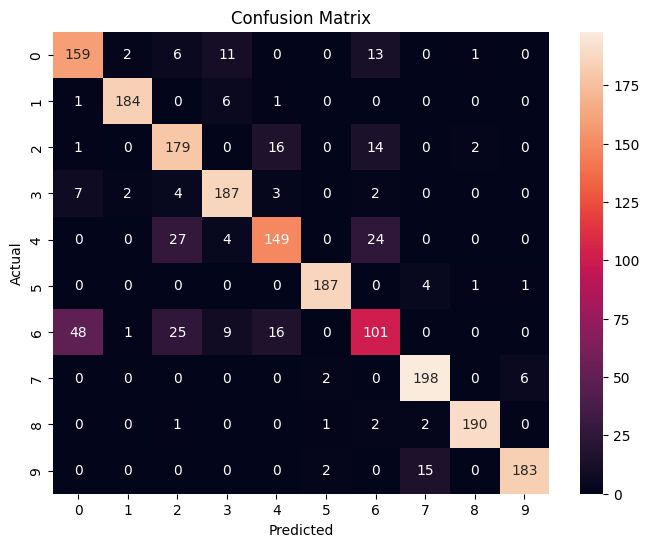

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

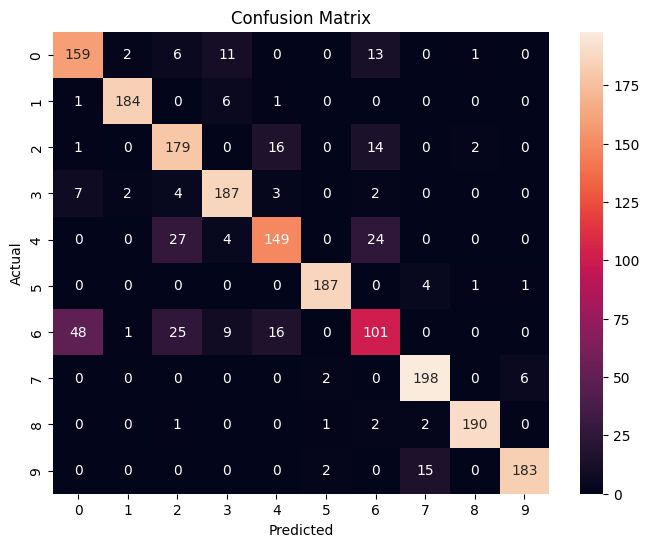

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

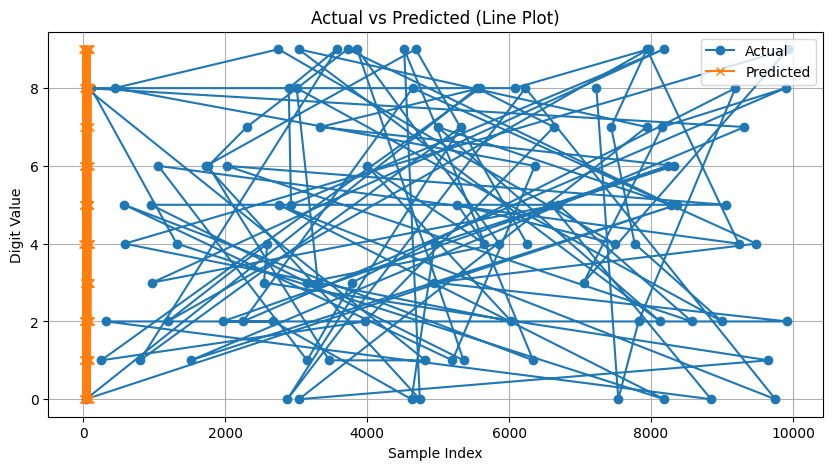

In [39]:
plt.figure(figsize=(10,5))
plt.plot(y_test[:100], label="Actual", marker='o')
plt.plot(y_pred[:100], label="Predicted", marker='x')

plt.xlabel("Sample Index")
plt.ylabel("Digit Value")
plt.title("Actual vs Predicted (Line Plot)")
plt.legend()
plt.grid()
plt.show()

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8585
